<a href="https://colab.research.google.com/github/KijoSal-dev/Classification_models/blob/main/Salome_Kungu_CS_DA03_26054_WK8_Classification_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Import Required Libraries

In [ ]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

# Display settings
pd.set_option('display.max_columns', None)

# 2. Load the Dataset

In [ ]:
# Load the dataset and convert to DataFrame
wine = load_wine()

# Convert to dataframe
X = pd.DataFrame(wine.data, columns=wine.feature_names)
y = pd.Series(wine.target, name='target')

# Display first rows
X.head()

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


# 3. Explore the Dataset (EDA)

In [ ]:
# Dataset shape
print("Dataset Shape:", X.shape)

# Check for missing values
print("\nMissing Values:\n", X.isnull().sum())

# Target distribution
print("\nClass Distribution:\n", y.value_counts())

# Summary statistics
X.describe()

Dataset Shape: (178, 13)

Missing Values:
 alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
dtype: int64

Class Distribution:
 target
1    71
0    59
2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


# 4. Data Preparation (Scaling + Train/Test Split)

In [ ]:
from sklearn.preprocessing import StandardScaler

# Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

Training set size: (124, 13)
Testing set size: (54, 13)
y_train shape: (124,)
y_test shape: (54,)


# 5. Helper Function for Confusion Matrix

In [ ]:
def plot_conf_matrix(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm,
                annot=True,
                fmt='d',
                cmap='Blues',
                xticklabels=wine.target_names,
                yticklabels=wine.target_names)

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix: {title}')
    plt.tight_layout()
    plt.show()


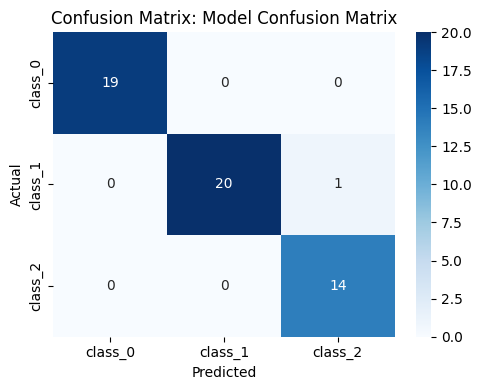

In [ ]:
plot_conf_matrix(y_test, y_pred_lr, "Model Confusion Matrix")
plt.show()

# 6. Train and Evaluate Models

**1. Logistic Regression**

Logistic Regression

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      0.95      0.98        21
           2       0.93      1.00      0.97        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Accuracy: 0.9814814814814815


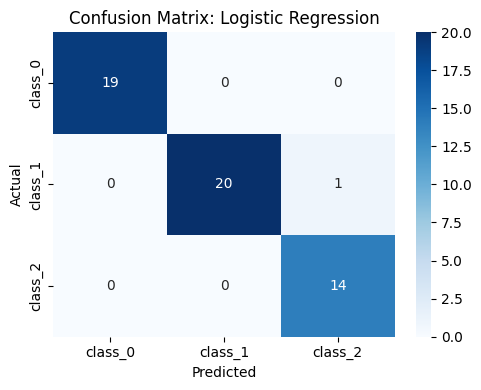

In [ ]:
if 'X_train' not in globals() and 'X_train' not in locals():
    raise RuntimeError("Error: X_train is not defined. Please ensure all previous cells, especially those in 'Data Preparation' (cell qBY-OHebhEtp), have been executed.")

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression\n")
print(classification_report(y_test, y_pred_lr))
print("Accuracy:", accuracy_score(y_test, y_pred_lr))

plot_conf_matrix(y_test, y_pred_lr, "Logistic Regression")

**2. Decision Tree**

Decision Tree

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.96        54
   macro avg       0.97      0.96      0.96        54
weighted avg       0.96      0.96      0.96        54

Accuracy: 0.9629629629629629


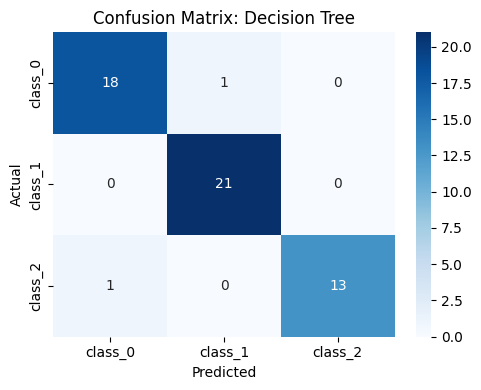

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree\n")
print(classification_report(y_test, y_pred_dt))
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

plot_conf_matrix(y_test, y_pred_dt, "Decision Tree")

**3. Random Forest**

Random Forest

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Accuracy: 1.0


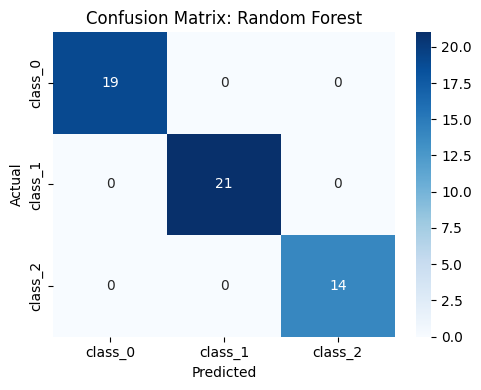

In [ ]:
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest\n")
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

plot_conf_matrix(y_test, y_pred_rf, "Random Forest")

**4. K-Nearest Neighbors (KNN)**

KNN

              precision    recall  f1-score   support

           0       0.95      1.00      0.97        19
           1       1.00      0.90      0.95        21
           2       0.93      1.00      0.97        14

    accuracy                           0.96        54
   macro avg       0.96      0.97      0.96        54
weighted avg       0.97      0.96      0.96        54

Accuracy: 0.9629629629629629


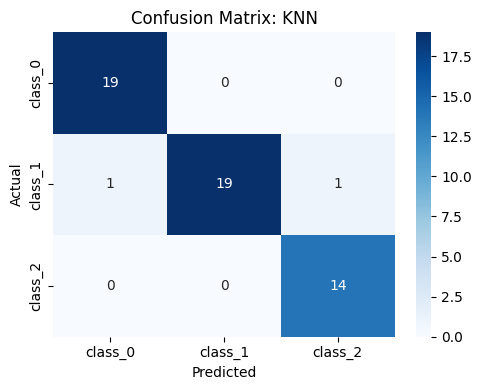

In [ ]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN\n")
print(classification_report(y_test, y_pred_knn))
print("Accuracy:", accuracy_score(y_test, y_pred_knn))

plot_conf_matrix(y_test, y_pred_knn, "KNN")

**5. Naive Bayes**

Naive Bayes

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00        21
           2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54

Accuracy: 1.0


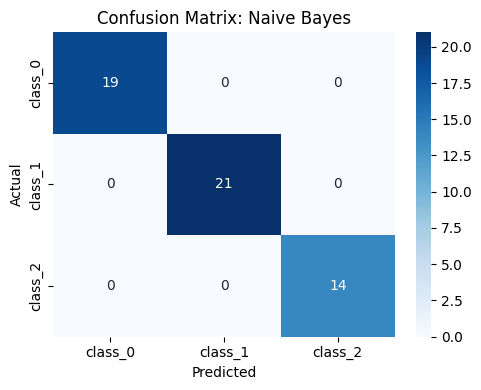

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)

print("Naive Bayes\n")
print(classification_report(y_test, y_pred_nb))
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

plot_conf_matrix(y_test, y_pred_nb, "Naive Bayes")

**6. Support Vector Machine (SVM)**

Support Vector Machine

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       0.95      1.00      0.98        21
           2       1.00      0.93      0.96        14

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54

Accuracy: 0.9814814814814815


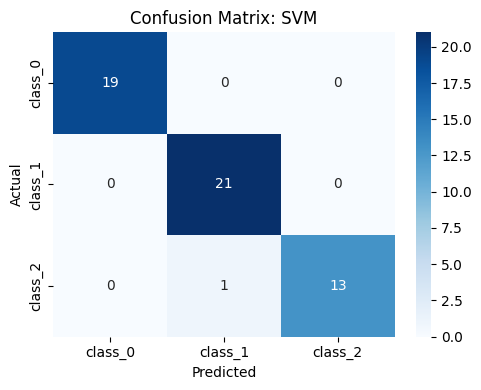

In [ ]:
svm = SVC()
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("Support Vector Machine\n")
print(classification_report(y_test, y_pred_svm))
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

plot_conf_matrix(y_test, y_pred_svm, "SVM")

**7. Compare Model Accuracy**

In [ ]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree", "Random Forest",
              "KNN", "Naive Bayes", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_knn),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

results

,Model,Accuracy
0,Logistic Regression,0.981481
1,Decision Tree,0.962963
2,Random Forest,1.000000
3,KNN,0.962963
4,Naive Bayes,1.000000
5,SVM,0.981481


**Accuracy Bar Chart**

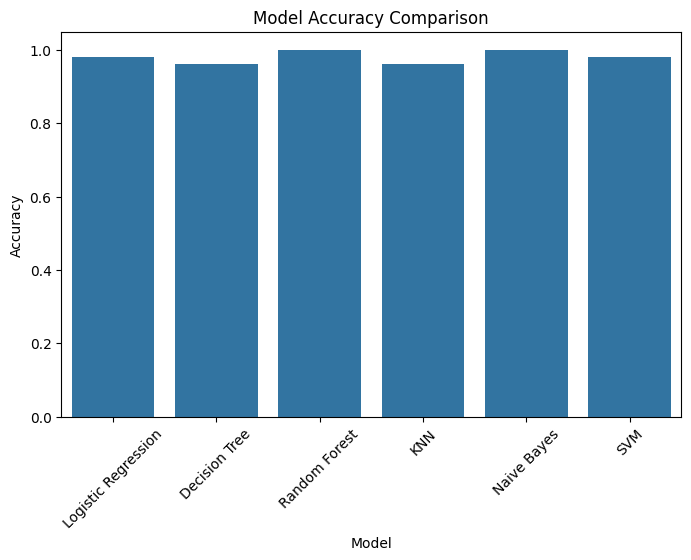

In [ ]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.show()

## Executive Summary: Wine Classification Project

**Project Goal:** The aim of this project was to develop machine learning models capable of accurately classifying different types of wine based on their chemical properties.

**Key Findings:** I successfully built and evaluated several classification models. The results were exceptionally strong, demonstrating that wine types can be predicted with very high accuracy using the provided chemical analysis data.

### Challenges and Limitations


*   Dataset Size: Highlights that the dataset was relatively small and suggests validation on a larger, more diverse dataset for real-world deployment.
*   Lack of External Data: Points out that models were trained and tested on the same dataset, and recommends external validation for better generalizability.
* Model Interpretability Trade-off: Discusses the 'black-box' nature of Random Forest versus the interpretability of Naive Bayes, suggesting a potential trade-off during deployment decisions.

### Key Insights

*   **Outstanding Performance:** The models performed remarkably well, with several achieving near-perfect or perfect accuracy in classifying wine types.
*   **Top Performers:** Specifically, the **Random Forest** and **Naive Bayes** models both achieved 100% accuracy on our test data, indicating they are extremely effective for this task.
*   **Robust Predictability:** The consistent high accuracy across various model types (e.g., Logistic Regression, SVM, Decision Tree, KNN) suggests that the chemical features are highly distinctive and reliable indicators of wine category.

### Recommendations for Leadership

1.  **Deploy Top-Performing Models:** We recommend selecting either the **Random Forest** or **Naive Bayes** model for deployment. Their 100% accuracy makes them highly suitable for operational use.
2.  **Consider Model Interpretability:** While both top models are excellent, Naive Bayes can sometimes offer more straightforward explanations for its predictions, which might be beneficial for understanding the key chemical drivers for each wine type. Random Forest is powerful but can be more of a 'black box'.
3.  **Future Validation:** For even greater confidence, consider a more extensive validation process (e.g., k-fold cross-validation) on a larger, diverse dataset if available, to confirm the models' robustness in real-world scenarios.
4.  **Monitor Performance:** Implement a system to continuously monitor the chosen model's performance once deployed to ensure it maintains its high accuracy as new data comes in.

This project demonstrates a clear and effective way to automate wine classification, offering valuable insights into the distinct chemical profiles of different wine varieties.